In [1]:
import math

import matplotlib.pyplot as plt
import torch
from PIL import Image
from torch import nn
from torch.nn import functional as F
from torchvision.transforms.functional import to_pil_image, to_tensor

from dct_autoencoder import (
    DCTBasis,
    get_dct_basis,
)
from dct_autoencoder.utils import rgb_to_ycbcr, ycbcr_to_rgb
from dct_autoencoder.visualization import visualize_dct_basis_functions


In [2]:
torch.backends.mps.is_built(), torch.backends.mps.is_available()

(True, True)

In [ ]:
class DCTAutoencoder(nn.Module):
    """DCT Autoencoder.

    Args:
        block_size (int, optional): The block size. Defaults to 8.
    """

    def __init__(
        self,
        block_size: int = 8,
    ) -> None:
        super().__init__()
        dct_basis = get_dct_basis(block_size)
        basis_functions = dct_basis.basis_functions
        kernels = basis_functions.reshape(-1, block_size, block_size)
        spatial_frequencies_magnitude = dct_basis.spatial_frequencies_magnitude.reshape(
            -1
        )
        spatial_frequencies_components = (
            dct_basis.spatial_frequencies_components.reshape(-1, 2)
        )
        sort_indices = torch.argsort(spatial_frequencies_magnitude)
        kernels = kernels[sort_indices]
        spatial_frequencies_magnitude = spatial_frequencies_magnitude[sort_indices]
        spatial_frequencies_components = spatial_frequencies_components[sort_indices]
        kernels = kernels[:, None, :, :]
        multiplication_factor_scalar = dct_basis.multiplication_factor_scalar
        multiplication_factor_matrix = dct_basis.multiplication_factor_matrix
        multiplication_factor_matrix = multiplication_factor_matrix.reshape(-1)
        multiplication_factor_matrix = multiplication_factor_matrix[sort_indices]
        multiplication_factor_matrix = multiplication_factor_matrix[None, :, None, None]
        self.register_buffer("kernels", kernels)
        self.register_buffer("block_size", torch.tensor(block_size))
        self.register_buffer(
            "multiplication_factor_scalar", torch.tensor(multiplication_factor_scalar)
        )
        self.register_buffer(
            "multiplication_factor_matrix", multiplication_factor_matrix
        )


    def encode(self, x: torch.Tensor) -> torch.Tensor:
        """Encodes the input RGB images.

        Args:
            x (torch.Tensor): Shape (B, C, H, W)

        Returns:
            torch.Tensor: DCT transorm shape (B, C * block_size^2, H // block_size, W // block_size)
        """
        b, c, h, w = x.shape
        if h % self.block_size != 0 or w % self.block_size != 0:
            raise ValueError("Dimensions must be divisible by the block size")

        # DCT encode
        y = (
            self.multiplication_factor_scalar
            * self.multiplication_factor_matrix
            * F.conv2d(x.view(-1, 1, h, w), self.kernels, stride=self.block_size.item())
        )
        y = y / self.block_size
        return y.reshape(
            b, -1, h // self.block_size.item(), w // self.block_size.item()
        )

    def decode(self, x: torch.Tensor) -> torch.Tensor:
        """Decodes the input encoded images.

        Args:
            encodings_batch (torch.Tensor): The input encoded images.

        Returns:
            torch.Tensor: The decoded images.
        """
        b, c, h, w = x.shape
        if c % self.block_size**2 != 0:
            raise ValueError("Channels must be divisible by the block_size^2")
        # scale up
        x = x * self.block_size
        org_ch = self.block_size**2
        # y = encodings_batch[:, :org_ch, :, :]
        # cb = encodings_batch[:, org_ch : org_ch * 2, :, :]
        # cr = encodings_batch[:, org_ch * 2 :, :, :]

        # DCT Decode
        # c1 = self.multiplication_factor_scalar
        # c2 = self.multiplication_factor_matrix
        y = self.multiplication_factor_scalar * F.conv_transpose2d(
            x.view(-1, org_ch, h, w) * self.multiplication_factor_matrix,
            self.kernels,
            stride=self.block_size.item(),
        )

        # ycbcr_tsr = ycbcr_tsr / 2 + 0.5
        # rgb_images_batch = ycbcr_to_rgb(ycbcr_tsr)
        return y.reshape(b, -1, h * self.block_size.item(), w * self.block_size.item())


## Basis

dct_basis.basis_functions.shape=torch.Size([8, 8, 8, 8])
dct_basis.spatial_frequencies_components.shape=torch.Size([8, 8, 2])
dct_basis.spatial_frequencies_magnitude.shape=torch.Size([8, 8])
dct_basis.multiplication_factor_matrix.shape=torch.Size([8, 8])
dct_basis.multiplication_factor_scalar=0.25
dct_basis.block_size=8


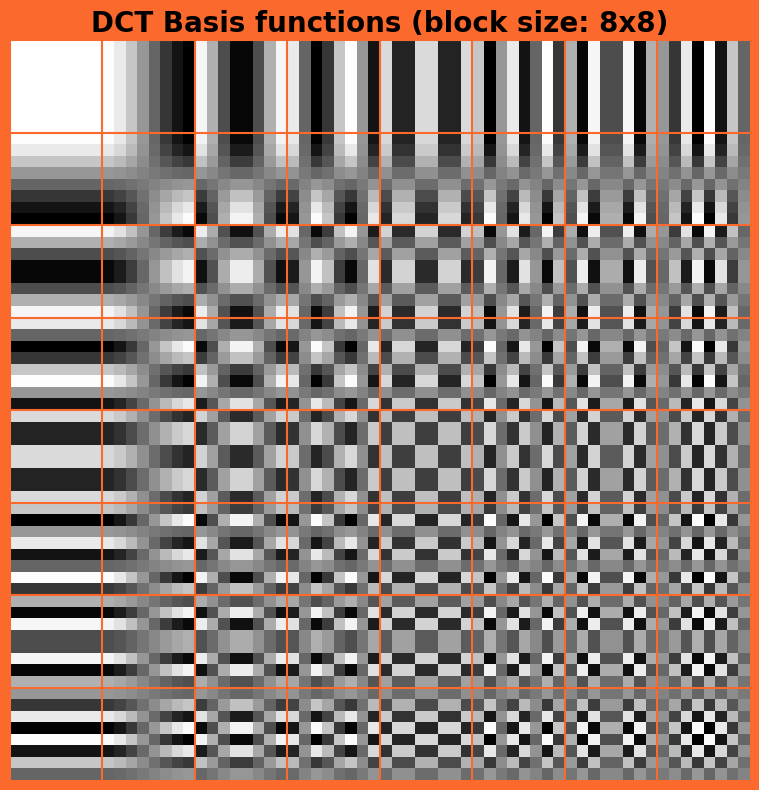

In [13]:
dct_basis: DCTBasis = get_dct_basis(block_size=8)
print(f"{dct_basis.basis_functions.shape=}")
print(f"{dct_basis.spatial_frequencies_components.shape=}")
print(f"{dct_basis.spatial_frequencies_magnitude.shape=}")
print(f"{dct_basis.multiplication_factor_matrix.shape=}")
print(f"{dct_basis.multiplication_factor_scalar=}")
print(f"{dct_basis.block_size=}")
fig, ax = visualize_dct_basis_functions(dct_basis)
plt.show()

## DCTAutoEncoder

In [14]:
block_size = 8
dct_autoencoder = DCTAutoencoder(
    block_size=block_size,
)
isinstance(dct_autoencoder, torch.nn.Module)

True

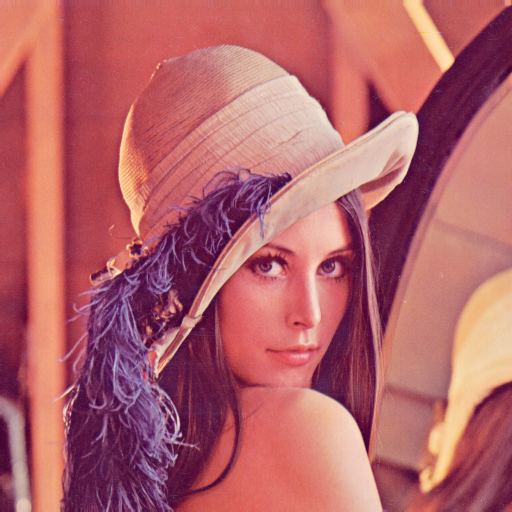

In [15]:
image = Image.open("assets/test_images/Lenna_(test_image).png")
image

In [16]:
for name, param in dct_autoencoder.named_parameters():
    print(f"Parameter: {name}, Type: {param.dtype}")

for name, buffer in dct_autoencoder.named_buffers():
    print(f"Buffer: {name}, Type: {buffer.dtype}")

Buffer: kernels, Type: torch.float32
Buffer: block_size, Type: torch.int64
Buffer: multiplication_factor_scalar, Type: torch.float32
Buffer: multiplication_factor_matrix, Type: torch.float32


In [17]:
for name, param in dct_autoencoder.named_parameters():
    print(f"Parameter: {name}, Device: {param.device}")

for name, buffer in dct_autoencoder.named_buffers():
    print(
        f"Buffer: {name}, Device: {buffer.device}, {buffer.is_contiguous(memory_format=torch.channels_last)}"
    )

Buffer: kernels, Device: cpu, True
Buffer: block_size, Device: cpu, False
Buffer: multiplication_factor_scalar, Device: cpu, False
Buffer: multiplication_factor_matrix, Device: cpu, True


### Encoding

In [24]:
device = torch.device("mps")
dct_autoencoder.to(device, memory_format=torch.channels_last)
# dct_autoencoder.to(device, memory_format=torch.channels_last)
image_tensor = to_tensor(image)
print(f"{image_tensor.shape=}")
batch = (
    image_tensor.unsqueeze(0)
    .to(device, memory_format=torch.channels_last)
    .tile(300, 1, 1, 1)
)
dct_encodings = dct_autoencoder.encode(batch)
print(f"{dct_encodings.shape=}")

image_tensor.shape=torch.Size([3, 512, 512])
dct_encodings.shape=torch.Size([300, 192, 64, 64])


In [ ]:
device = torch.device("mps")
dct_autoencoder.to(device, memory_format=torch.contiguous_format)
# dct_autoencoder.to(device, memory_format=torch.channels_last)
image_tensor = to_tensor(image)
print(f"{image_tensor.shape=}")
batch = (
    image_tensor.unsqueeze(0)
    .to(device, memory_format=torch.contiguous_format)
    .tile(300, 1, 1, 1)
)
dct_encodings = dct_autoencoder.encode(batch)
print(f"{dct_encodings.shape=}")

image_tensor.shape=torch.Size([3, 512, 512])
dct_encodings.shape=torch.Size([300, 192, 64, 64])


In [26]:
%timeit dct_encodings = dct_autoencoder.encode(batch)

78.2 ms ± 179 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [22]:
device = torch.device("cpu")
dct_autoencoder.to(device, memory_format=torch.contiguous_format)
image_tensor = to_tensor(image)
print(f"{image_tensor.shape=}")
batch = image_tensor.unsqueeze(0).to(device).tile(300, 1, 1, 1)
dct_encodings = dct_autoencoder.encode(batch)
print(f"{dct_encodings.shape=}")

image_tensor.shape=torch.Size([3, 512, 512])
dct_encodings.shape=torch.Size([300, 192, 64, 64])


In [12]:
dct_encodings[0:1].shape

torch.Size([1, 192, 64, 64])

### Decoding

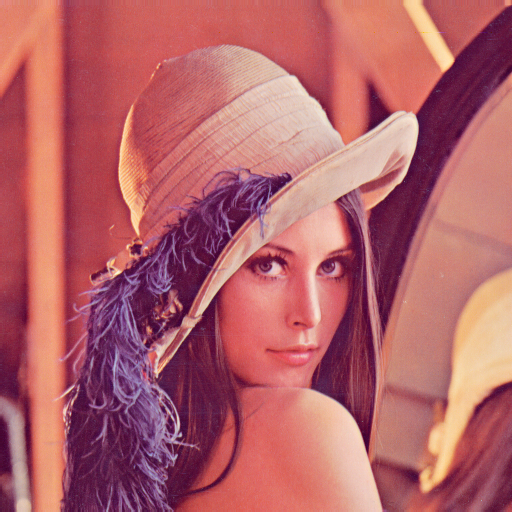

In [27]:
reconstructed_batch = dct_autoencoder.decode(dct_encodings[5:6])
reconstructed_image = reconstructed_batch.squeeze(0)
# torch.testing.assert_close(batch, reconstructed_batch, rtol=1e-3, atol=1e-3)
to_pil_image(reconstructed_image)

### Compress

In [15]:
compressed_dct_encodings = dct_autoencoder.compress(dct_encodings)
print(f"{compressed_dct_encodings.shape=}")
compression_ratio = dct_encodings.numel() / compressed_dct_encodings.numel()
print(f"{compression_ratio=}")

compressed_dct_encodings.shape=torch.Size([1, 24, 64, 64])
compression_ratio=8.0


## Decompress

decompressed_dct_encodings.shape=torch.Size([1, 192, 64, 64])


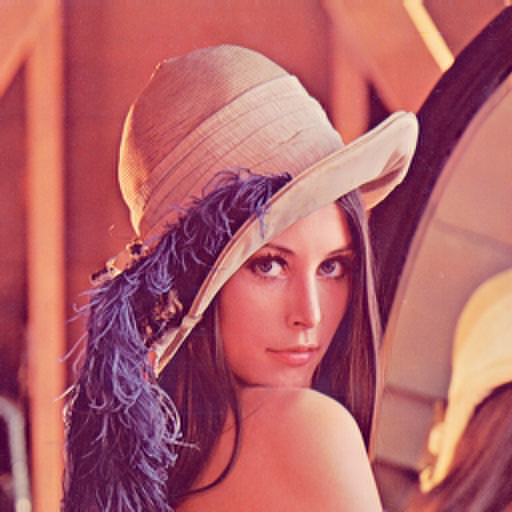

In [16]:
decompressed_dct_encodings = dct_autoencoder.decompress(compressed_dct_encodings)
print(f"{decompressed_dct_encodings.shape=}")
decompressed_batch = dct_autoencoder.decode(decompressed_dct_encodings)
decompressed_image = decompressed_batch.squeeze(0)
to_pil_image(decompressed_image)